# 05 · Exploratory Data Analysis (EDA)

**Difficulty:** Intermediate | **Time:** ~3 hours

EDA is the most important step in any data science project. Before modeling, you must *understand* your data.

## Table of Contents
1. EDA Framework
2. Univariate Analysis
3. Bivariate Analysis
4. Multivariate Analysis
5. Outlier Detection
6. Feature Distributions & Skewness
7. Complete EDA Project: House Price Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Realistic House Price Dataset
np.random.seed(42)
n = 500

area      = np.random.randint(600, 4000, n)
bedrooms  = np.random.choice([1,2,3,4,5], n, p=[0.05,0.25,0.40,0.20,0.10])
bathrooms = np.clip(bedrooms - 1 + np.random.randint(0, 2, n), 1, 4)
age       = np.random.randint(0, 50, n)
distance_cbd = np.random.randint(1, 40, n)
floors    = np.random.choice([1,2,3], n, p=[0.5,0.35,0.15])
location  = np.random.choice(['Urban','Suburb','Rural'], n, p=[0.4,0.45,0.15])
parking   = np.random.choice([0,1,2], n, p=[0.2,0.5,0.3])

# Price with realistic correlations
price = (area * 45
         + bedrooms * 8000
         + bathrooms * 12000
         - age * 1500
         - distance_cbd * 3000
         + floors * 5000
         + parking * 10000
         + np.where(location=='Urban', 50000, np.where(location=='Suburb', 20000, 0))
         + np.random.normal(0, 25000, n))
price = price.clip(300000, 3000000).astype(int)

houses = pd.DataFrame({
    'Price': price, 'Area': area, 'Bedrooms': bedrooms,
    'Bathrooms': bathrooms, 'Age': age, 'Distance_CBD': distance_cbd,
    'Floors': floors, 'Location': location, 'Parking': parking
})
print("Dataset shape:", houses.shape)
print(houses.head())

Dataset shape: (500, 9)
    Price  Area  Bedrooms  Bathrooms  Age  Distance_CBD  Floors Location  \
0  300000  3774         3          3   34            14       1    Urban   
1  300000  1460         4          3   38            39       2   Suburb   
2  300000  1894         5          4   45            25       1   Suburb   
3  300000  1730         3          2   28            20       2   Suburb   
4  300000  1695         3          2   48             2       1    Rural   

   Parking  
0        2  
1        0  
2        0  
3        0  
4        1  


## 1. EDA Framework — Always Follow This

In [2]:
print("=" * 50)
print("STEP 1: Basic Info")
print("=" * 50)
print(f"Rows: {houses.shape[0]}, Columns: {houses.shape[1]}")
print(f"\nColumn types:")
print(houses.dtypes)

print("\n" + "=" * 50)
print("STEP 2: Missing Values")
print("=" * 50)
missing = houses.isnull().sum()
missing_pct = (missing / len(houses) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct%': missing_pct}))

print("\n" + "=" * 50)
print("STEP 3: Duplicate Rows")
print("=" * 50)
print(f"Duplicates: {houses.duplicated().sum()}")

print("\n" + "=" * 50)
print("STEP 4: Statistical Summary")
print("=" * 50)
print(houses.describe().round(2))

STEP 1: Basic Info
Rows: 500, Columns: 9

Column types:
Price           int64
Area            int64
Bedrooms        int64
Bathrooms       int64
Age             int64
Distance_CBD    int64
Floors          int64
Location          str
Parking         int64
dtype: object

STEP 2: Missing Values
              Missing  Pct%
Price               0   0.0
Area                0   0.0
Bedrooms            0   0.0
Bathrooms           0   0.0
Age                 0   0.0
Distance_CBD        0   0.0
Floors              0   0.0
Location            0   0.0
Parking             0   0.0

STEP 3: Duplicate Rows
Duplicates: 0

STEP 4: Statistical Summary
           Price     Area  Bedrooms  Bathrooms     Age  Distance_CBD  Floors  \
count     500.00   500.00    500.00     500.00  500.00        500.00  500.00   
mean   300249.31  2347.62      3.06       2.51   24.79         19.63    1.67   
std      3375.62   967.73      1.03       1.04   14.27         11.50    0.71   
min    300000.00   601.00      1.00      

## 2. Univariate Analysis — Each Variable Alone

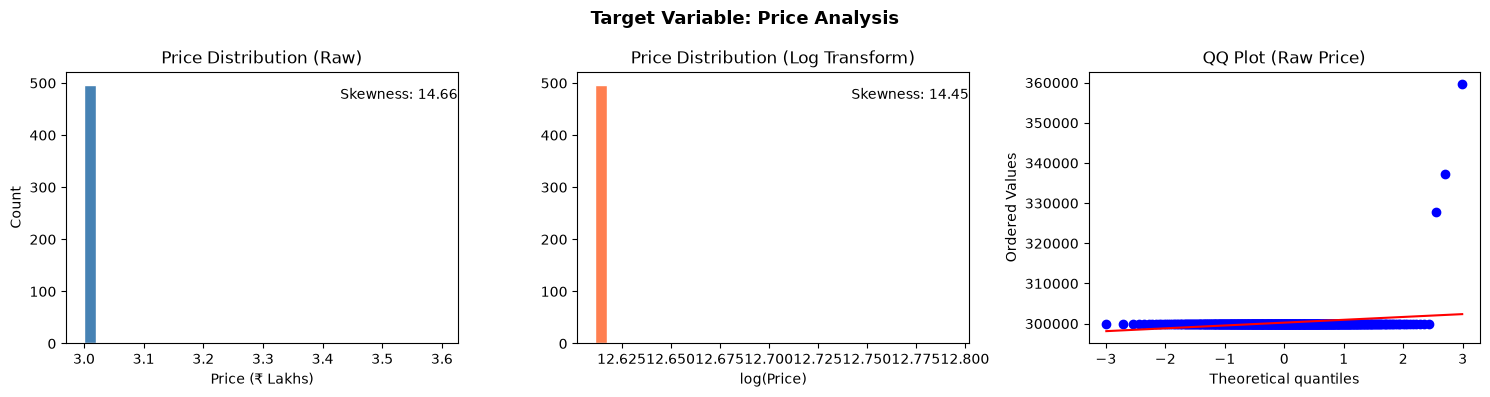

Skewness raw=14.66, log=14.45 | Closer to 0 is better for ML


In [3]:
# Analyze the TARGET variable first
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
axes[0].hist(houses['Price']/100000, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Price Distribution (Raw)")
axes[0].set_xlabel("Price (₹ Lakhs)")
axes[0].set_ylabel("Count")
skew_raw = stats.skew(houses['Price'])
axes[0].text(0.7, 0.9, f'Skewness: {skew_raw:.2f}', transform=axes[0].transAxes, fontsize=10)

# Log transform
log_price = np.log1p(houses['Price'])
axes[1].hist(log_price, bins=30, color='coral', edgecolor='white')
axes[1].set_title("Price Distribution (Log Transform)")
axes[1].set_xlabel("log(Price)")
skew_log = stats.skew(log_price)
axes[1].text(0.7, 0.9, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes, fontsize=10)

# QQ plot — checking normality
stats.probplot(houses['Price'], dist='norm', plot=axes[2])
axes[2].set_title("QQ Plot (Raw Price)")

plt.suptitle("Target Variable: Price Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/eda_target.png", dpi=100)
plt.show()
print(f"Skewness raw={skew_raw:.2f}, log={skew_log:.2f} | Closer to 0 is better for ML")

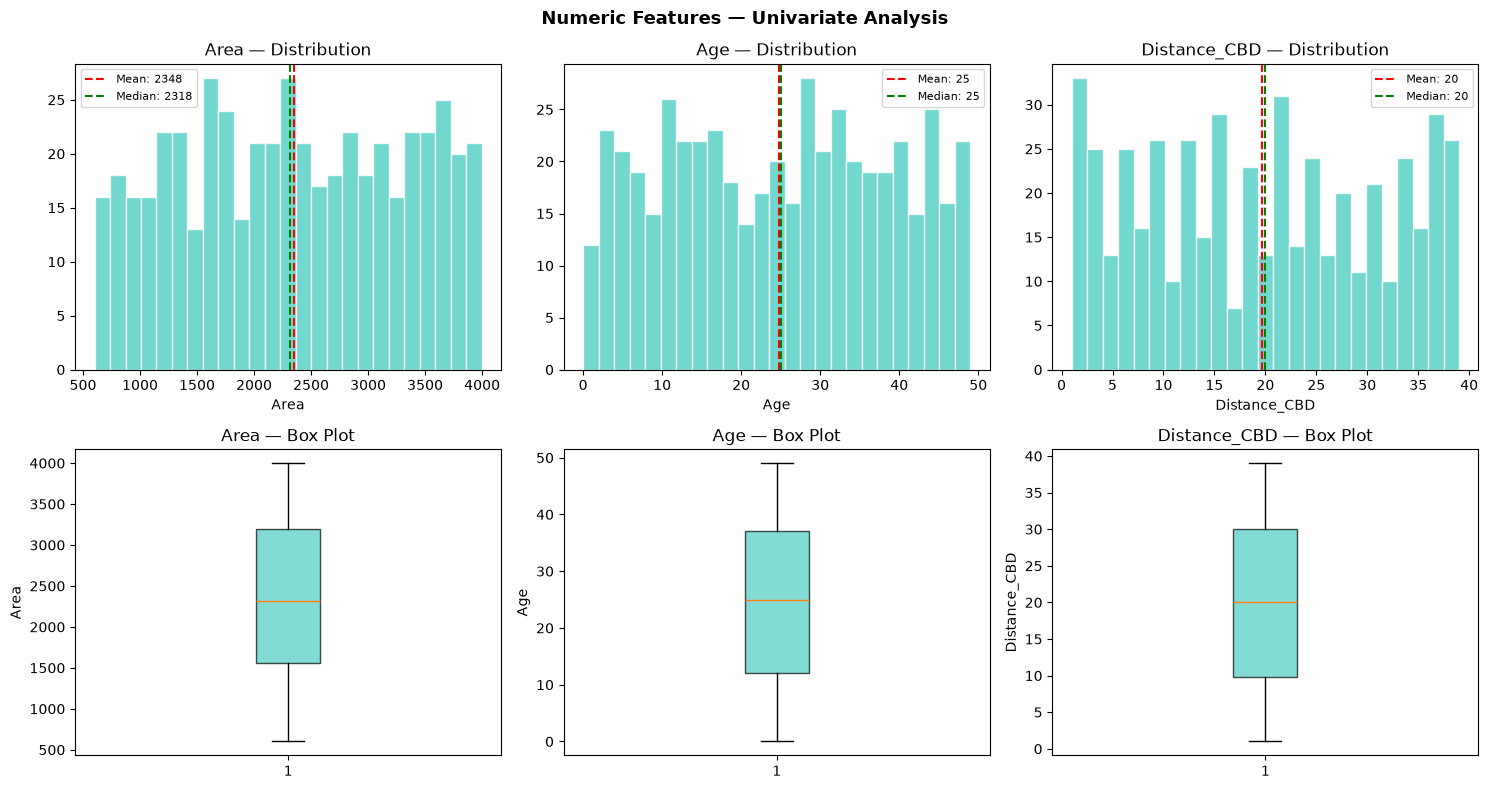

In [4]:
# Numeric features distribution
numeric_cols = ['Area','Age','Distance_CBD']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    data = houses[col]
    
    # Histogram
    axes[0,i].hist(data, bins=25, color='#4ECDC4', edgecolor='white', alpha=0.8)
    axes[0,i].set_title(f"{col} — Distribution")
    axes[0,i].set_xlabel(col)
    axes[0,i].axvline(data.mean(), color='red', ls='--', label=f'Mean: {data.mean():.0f}')
    axes[0,i].axvline(data.median(), color='green', ls='--', label=f'Median: {data.median():.0f}')
    axes[0,i].legend(fontsize=8)
    
    # Box plot
    axes[1,i].boxplot(data, patch_artist=True, 
                       boxprops=dict(facecolor='#4ECDC4', alpha=0.7))
    axes[1,i].set_title(f"{col} — Box Plot")
    axes[1,i].set_ylabel(col)

plt.suptitle("Numeric Features — Univariate Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/eda_univariate.png", dpi=100)
plt.show()

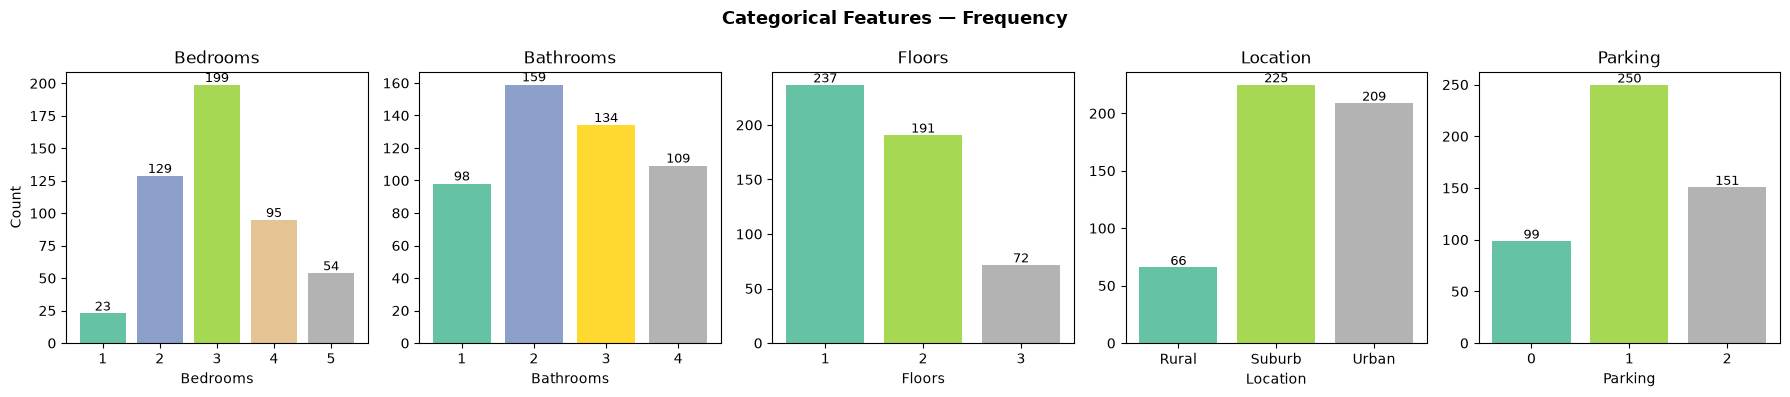

In [5]:
# Categorical features
cat_cols = ['Bedrooms','Bathrooms','Floors','Location','Parking']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(cat_cols):
    counts = houses[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, 
                color=plt.cm.Set2(np.linspace(0, 1, len(counts))))
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)
    if i == 0: axes[i].set_ylabel("Count")
    # Add value labels
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

plt.suptitle("Categorical Features — Frequency", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/eda_categorical.png", dpi=100)
plt.show()

## 3. Bivariate Analysis — Two Variables Together

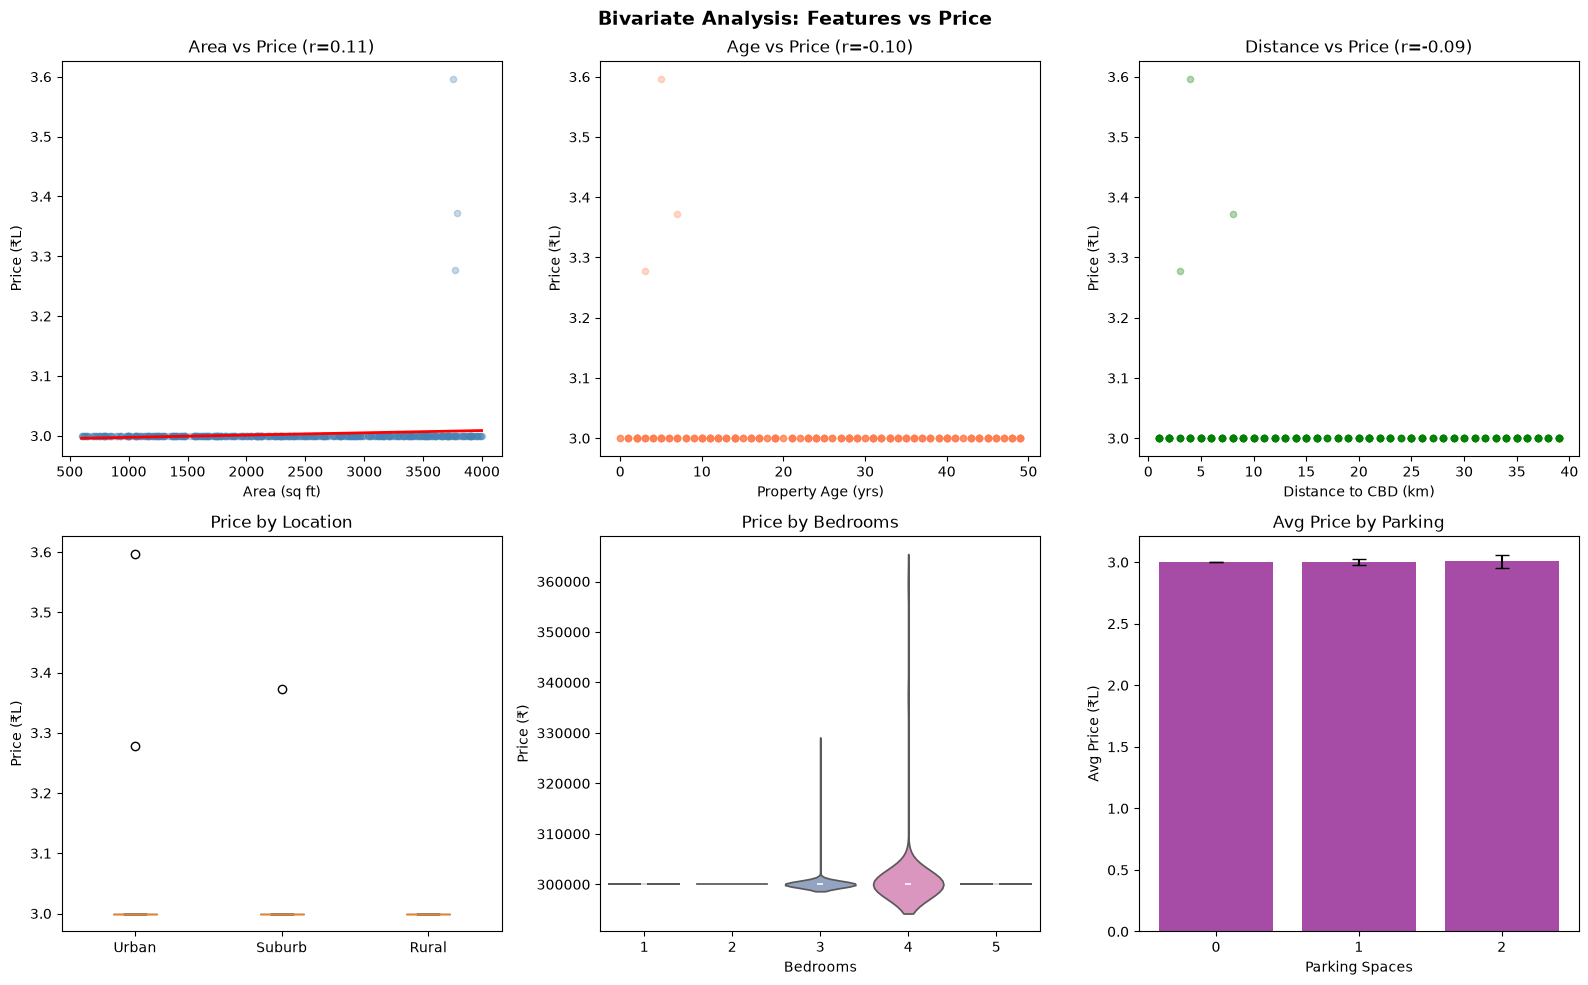

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Area vs Price
axes[0,0].scatter(houses['Area'], houses['Price']/100000, alpha=0.3, s=20, color='steelblue')
m, b = np.polyfit(houses['Area'], houses['Price']/100000, 1)
x_r = np.linspace(houses['Area'].min(), houses['Area'].max(), 100)
axes[0,0].plot(x_r, m*x_r + b, 'r-', linewidth=2)
axes[0,0].set_xlabel("Area (sq ft)"); axes[0,0].set_ylabel("Price (₹L)")
axes[0,0].set_title(f"Area vs Price (r={houses['Area'].corr(houses['Price']):.2f})")

# Age vs Price
axes[0,1].scatter(houses['Age'], houses['Price']/100000, alpha=0.3, s=20, color='coral')
axes[0,1].set_xlabel("Property Age (yrs)"); axes[0,1].set_ylabel("Price (₹L)")
axes[0,1].set_title(f"Age vs Price (r={houses['Age'].corr(houses['Price']):.2f})")

# Distance vs Price
axes[0,2].scatter(houses['Distance_CBD'], houses['Price']/100000, alpha=0.3, s=20, color='green')
axes[0,2].set_xlabel("Distance to CBD (km)"); axes[0,2].set_ylabel("Price (₹L)")
axes[0,2].set_title(f"Distance vs Price (r={houses['Distance_CBD'].corr(houses['Price']):.2f})")

# Price by Location (box)
location_order = ['Urban','Suburb','Rural']
data_loc = [houses[houses['Location']==loc]['Price']/100000 for loc in location_order]
bp = axes[1,0].boxplot(data_loc, tick_labels=location_order, patch_artist=True)
for p, c in zip(bp['boxes'], ['#FF6B6B','#4ECDC4','#FECA57']):
    p.set_facecolor(c)
axes[1,0].set_ylabel("Price (₹L)"); axes[1,0].set_title("Price by Location")

# Price by Bedrooms (violin)
sns.violinplot(data=houses, x='Bedrooms', y='Price', ax=axes[1,1], palette='Set2')
axes[1,1].set_ylabel("Price (₹)"); axes[1,1].set_title("Price by Bedrooms")

# Price by Parking (bar + error)
park_mean = houses.groupby('Parking')['Price'].mean() / 100000
park_std  = houses.groupby('Parking')['Price'].std()  / 100000
axes[1,2].bar(park_mean.index.astype(str), park_mean, 
              yerr=park_std, capsize=5, color='purple', alpha=0.7)
axes[1,2].set_xlabel("Parking Spaces"); axes[1,2].set_ylabel("Avg Price (₹L)")
axes[1,2].set_title("Avg Price by Parking")

plt.suptitle("Bivariate Analysis: Features vs Price", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/eda_bivariate.png", dpi=100)
plt.show()

## 4. Multivariate Analysis — Correlation Heatmap

Correlation with Price:
Price           1.000
Area            0.109
Age             0.102
Distance_CBD    0.094
Parking         0.063
Bedrooms        0.052
Floors          0.046
Bathrooms       0.035
Name: Price, dtype: float64


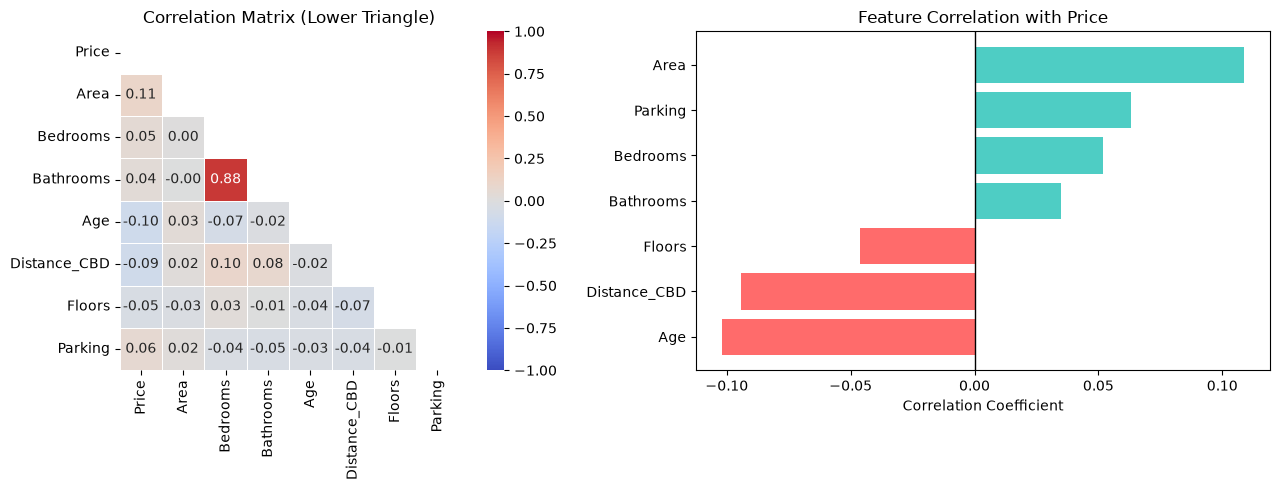

In [7]:
# Correlation matrix — the most important EDA tool
numeric_houses = houses.select_dtypes(include='number')
corr_matrix = numeric_houses.corr()

# Sort by correlation with Price
price_corr = corr_matrix['Price'].abs().sort_values(ascending=False)
print("Correlation with Price:")
print(price_corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[0].set_title("Correlation Matrix (Lower Triangle)")

# Bar chart of correlations with Price
corr_with_price = corr_matrix['Price'].drop('Price').sort_values()
colors = ['#FF6B6B' if v < 0 else '#4ECDC4' for v in corr_with_price]
axes[1].barh(corr_with_price.index, corr_with_price.values, color=colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title("Feature Correlation with Price")
axes[1].set_xlabel("Correlation Coefficient")

plt.tight_layout()
plt.savefig("/tmp/eda_correlation.png", dpi=100)
plt.show()

## 5. Outlier Detection

Price: 3 outliers (0.6%)
Area: 0 outliers (0.0%)
Age: 0 outliers (0.0%)


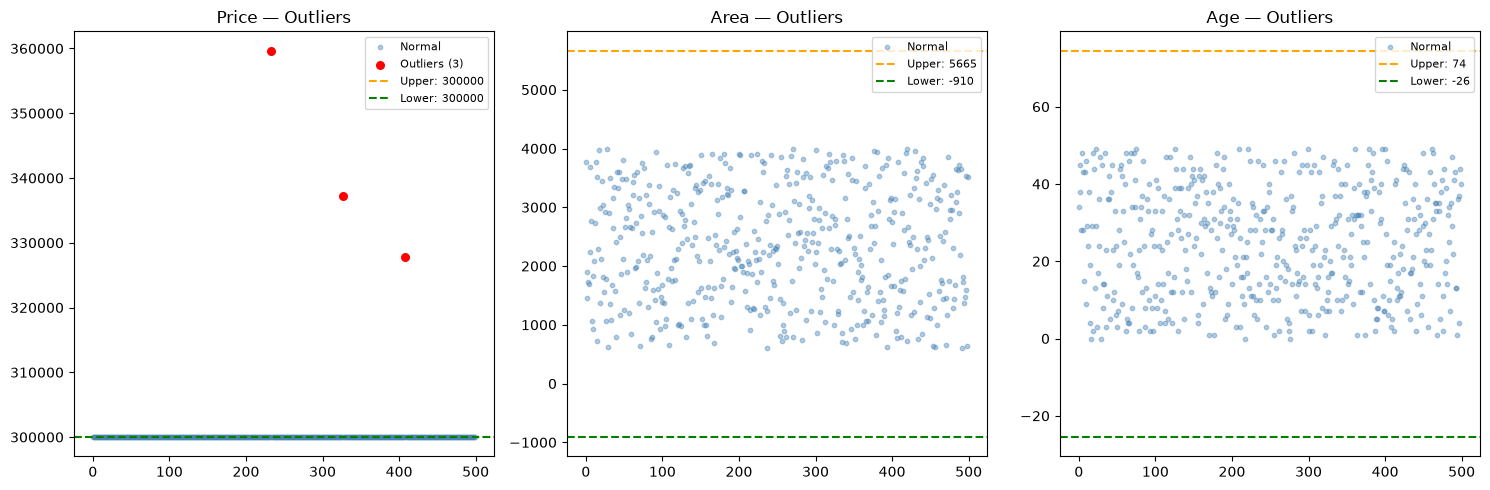

In [8]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['Price','Area','Age']):
    outliers, lower, upper = detect_outliers_iqr(houses[col])
    
    axes[i].scatter(range(len(houses)), houses[col], s=10, alpha=0.4, color='steelblue', label='Normal')
    if len(outliers):
        axes[i].scatter(outliers.index, outliers.values, s=30, color='red', label=f'Outliers ({len(outliers)})', zorder=5)
    axes[i].axhline(upper, color='orange', linestyle='--', linewidth=1.5, label=f'Upper: {upper:.0f}')
    axes[i].axhline(lower, color='green',  linestyle='--', linewidth=1.5, label=f'Lower: {lower:.0f}')
    axes[i].set_title(f"{col} — Outliers")
    axes[i].legend(fontsize=8)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(houses)*100:.1f}%)")

plt.tight_layout()
plt.savefig("/tmp/eda_outliers.png", dpi=100)
plt.show()

## 6. Feature Engineering from EDA Insights

In [9]:
# Based on EDA, create meaningful new features
houses_fe = houses.copy()

# Price per sq ft
houses_fe['Price_per_sqft'] = houses_fe['Price'] / houses_fe['Area']

# Total rooms
houses_fe['Total_rooms'] = houses_fe['Bedrooms'] + houses_fe['Bathrooms']

# Is new property?
houses_fe['Is_new'] = (houses_fe['Age'] <= 5).astype(int)

# Location encoded
loc_map = {'Urban': 3, 'Suburb': 2, 'Rural': 1}
houses_fe['Location_score'] = houses_fe['Location'].map(loc_map)

# Log price (normalized target)
houses_fe['Log_Price'] = np.log1p(houses_fe['Price'])

print("New features:")
print(houses_fe[['Price_per_sqft','Total_rooms','Is_new','Location_score','Log_Price']].describe().round(2))

New features:
       Price_per_sqft  Total_rooms  Is_new  Location_score  Log_Price
count          500.00       500.00  500.00          500.00     500.00
mean           161.40         5.56    0.11            2.29      12.61
std             92.20         2.01    0.32            0.68       0.01
min             75.06         2.00    0.00            1.00      12.61
25%             94.39         4.00    0.00            2.00      12.61
50%            129.39         5.00    0.00            2.00      12.61
75%            192.83         7.00    0.00            3.00      12.61
max            499.17         9.00    1.00            3.00      12.79


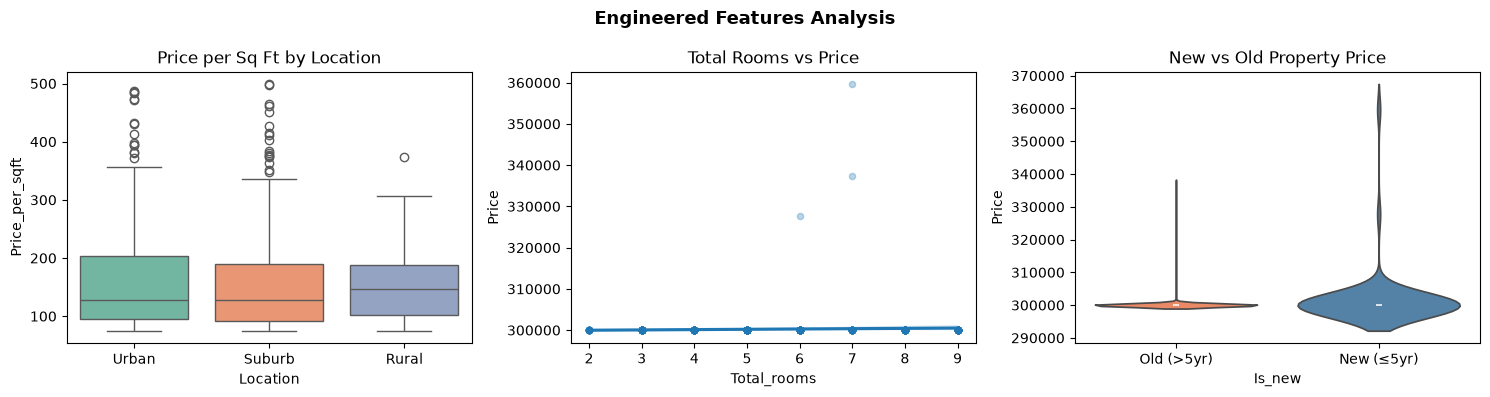

In [10]:
# Visualize engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price per sqft by Location
sns.boxplot(data=houses_fe, x='Location', y='Price_per_sqft', ax=axes[0], palette='Set2')
axes[0].set_title("Price per Sq Ft by Location")

# Total rooms vs Price
sns.regplot(data=houses_fe, x='Total_rooms', y='Price', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':20})
axes[1].set_title("Total Rooms vs Price")

# New vs Old house prices
sns.violinplot(data=houses_fe, x='Is_new', y='Price', ax=axes[2], palette=['coral','steelblue'])
axes[2].set_xticklabels(['Old (>5yr)','New (≤5yr)'])
axes[2].set_title("New vs Old Property Price")

plt.suptitle("Engineered Features Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/eda_engineered.png", dpi=100)
plt.show()

## EDA Checklist — Use This Every Time

```
✓ Check shape, dtypes, head/tail
✓ Count missing values + decide strategy
✓ Check for duplicates
✓ Descriptive statistics (mean, std, min, max, quartiles)
✓ Univariate: distribution of each feature
✓ Target variable: distribution, skewness, outliers
✓ Bivariate: each feature vs target (scatter, box, violin)
✓ Multivariate: correlation heatmap
✓ Outlier detection (IQR method)
✓ Feature engineering based on domain knowledge
```

**Next notebook →** `06_Feature_Engineering_Preprocessing.ipynb`